<a href="https://colab.research.google.com/github/davi-osilva/engenharia-machine-learning/blob/main/RegressaoLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Previsão da nota no ENADE a partir da regressão linear

In [ ]:
# Manipulação de dados
from google.colab import files
import pandas as pd
import numpy as np

# Plotação
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Exportar modelo
import joblib

In [ ]:
plt.style.use('default')
sns.set(font_scale=1.1)

##Carregar Dataset

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')

In [ ]:
df.head()

,sex,race/ethnicity,parental level of education,lunch,test preparation course,enade score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.columns = df.columns.str.replace(" ", "_")

##Análise Exploratória

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sex                          1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   enade_score                  1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,enade_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
numericas = list(df.select_dtypes(include=['int64']).columns)
numericas

['enade_score', 'reading_score', 'writing_score']

## Matriz de correlação

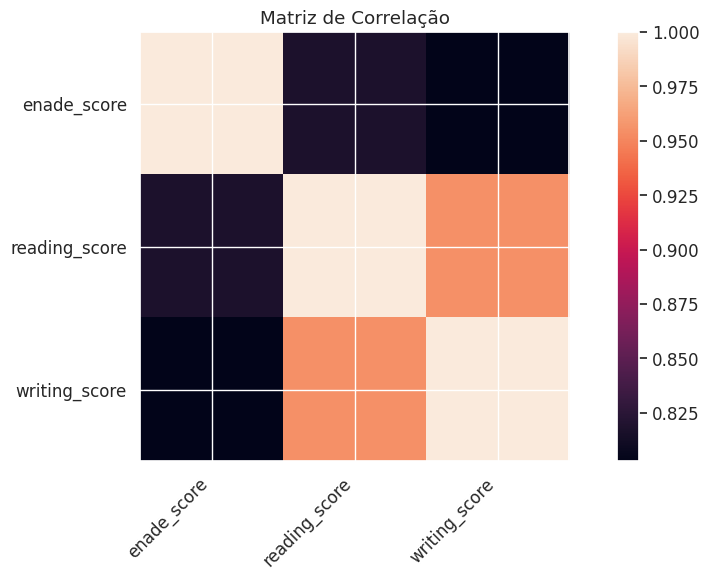

In [ ]:
corr = df[numericas].corr()

plt.figure(figsize=(10, 6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Matriz de Correlação')
plt.tight_layout()

plt.show()

## Preparação dos Dados

Text(0.5, 1.0, 'Boxplot das Variáveis Numéricas')

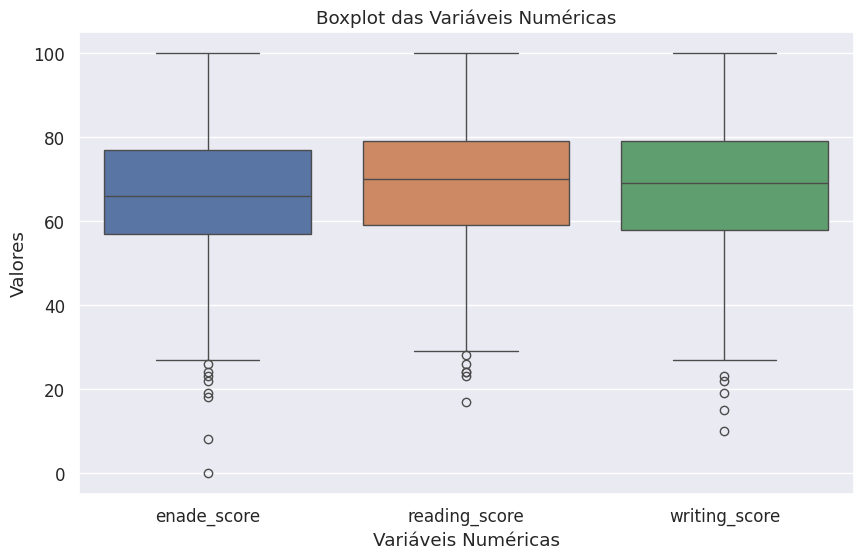

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numericas])

plt.xlabel('Variáveis Numéricas')
plt.ylabel('Valores')
plt.title('Boxplot das Variáveis Numéricas')

In [ ]:
def detectar_outlier(serie):

  Q1 = serie.quantile(0.25)
  Q3 = serie.quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  return limite_inferior, limite_superior

In [ ]:
for col in numericas:
  limite_inferior, limite_superior = detectar_outlier(df[col])
  qtd = df[(df[col] < limite_inferior) | (df[col] > limite_superior)].shape[0]

  print(f"Coluna: {col}, Quantidade de outlier: {qtd}, Limite inferior: {limite_inferior}, Limite superior: {limite_superior}")

Coluna: enade_score, Quantidade de outlier: 8, Limite inferior: 27.0, Limite superior: 107.0
Coluna: reading_score, Quantidade de outlier: 6, Limite inferior: 29.0, Limite superior: 109.0
Coluna: writing_score, Quantidade de outlier: 5, Limite inferior: 25.875, Limite superior: 110.875


In [ ]:
from numpy._core.defchararray import lower
# Winsorização

def winsorizacao(serie):
  limite_inferior, limite_superior = detectar_outlier(serie)

  serie_tratada = serie.clip(lower=limite_inferior, upper=limite_superior)

  return serie_tratada

In [ ]:
for col in numericas:
  df[col] = winsorizacao(df[col])

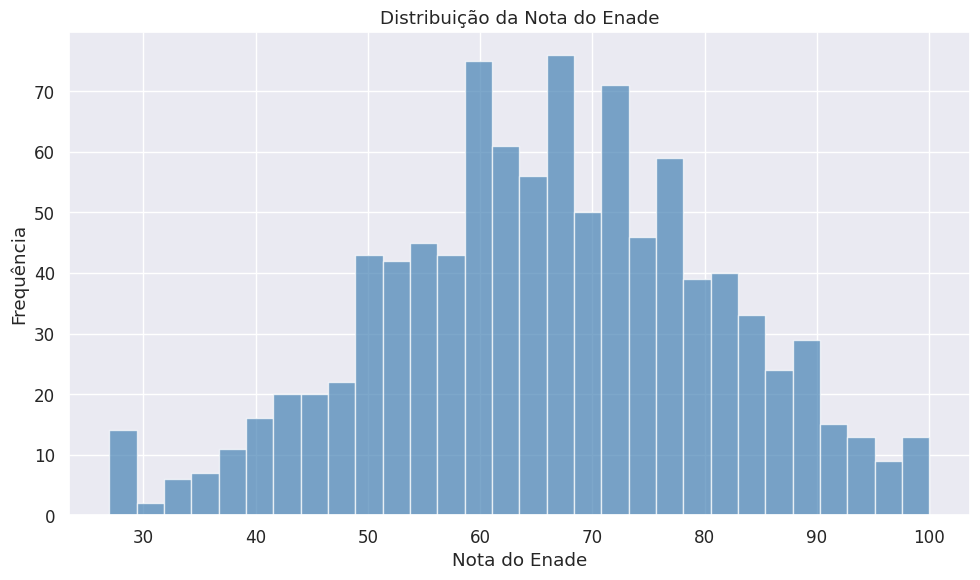

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['enade_score'], bins=30, alpha=0.7, color='steelblue')
plt.title('Distribuição da Nota do Enade')
plt.xlabel('Nota do Enade')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

## Codificando variáveis categóricas

In [ ]:
categoricas = list(df.select_dtypes(include=['object']).columns)
ohe = OneHotEncoder(drop='first', sparse_output=False)
df_ohe = pd.DataFrame(ohe.fit_transform(df[categoricas]), columns=ohe.get_feature_names_out())

df_encoded = pd.concat([df.drop(categoricas, axis=1), df_ohe], axis=1)

## Normalização

In [ ]:
colunas = ['reading_score', 'writing_score']
scaler = MinMaxScaler()

df_encoded[colunas] = scaler.fit_transform(df_encoded[colunas])

df_encoded

,enade_score,reading_score,writing_score,sex_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental_level_of_education_bachelor's degree,parental_level_of_education_high school,parental_level_of_education_master's degree,parental_level_of_education_some college,parental_level_of_education_some high school,lunch_standard,test_preparation_course_none
0,72,0.605634,0.649241,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,69,0.859155,0.838111,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,90,0.929577,0.905565,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,47,0.394366,0.244519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,76,0.690141,0.662732,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,88,0.985915,0.932546,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
996,62,0.366197,0.392917,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
997,59,0.591549,0.527825,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
998,68,0.690141,0.689713,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Separação da variável alvo

In [ ]:
X = df_encoded.drop('enade_score', axis=1)
y = df_encoded['enade_score']

In [ ]:
# Separação entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X[['reading_score']], y, test_size=0.3, random_state=42)

## Usando o modelo

In [ ]:
modelo_simples = LinearRegression()

modelo_simples.fit(X_train, y_train)

LinearRegression()

## Coeficientes do modelo

In [ ]:
b0 = modelo_simples.intercept_
b1 = modelo_simples.coef_[0]

print(f"Coeficiente angular (b1): {b1}")
print(f"Coeficiente linear (b0): {b0}")

Coeficiente angular (b1): 60.111113906751825
Coeficiente linear (b0): 32.11858994244924


In [ ]:
y_pred_simples = modelo_simples.predict(X_test)

## Visualização da reta

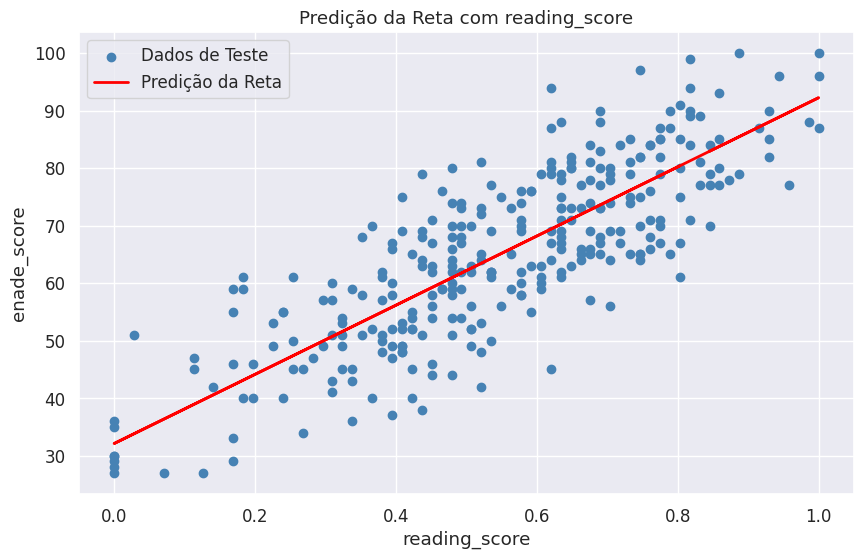

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='steelblue', label='Dados de Teste')
plt.plot(X_test, y_pred_simples, color='red', linewidth=2, label='Predição da Reta')
plt.xlabel('reading_score')
plt.ylabel('enade_score')
plt.title('Predição da Reta com reading_score')
plt.legend()
plt.show()

## Regressão Linear Múltipla

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train, y_train)

LinearRegression()

In [ ]:
coeficientes = {
    'nome': X.columns,
    'intercepto': modelo_multiplo.intercept_,
    'coeficiente_angular': modelo_multiplo.coef_
}

df_coeficientes = pd.DataFrame(coeficientes).sort_values(by='coeficiente_angular', ascending=False)
df_coeficientes

,nome,intercepto,coeficiente_angular
1,writing_score,15.73867,52.495085
0,reading_score,15.73867,17.267813
2,sex_male,15.73867,12.776506
6,race/ethnicity_group E,15.73867,4.534740
12,lunch_standard,15.73867,3.355933
13,test_preparation_course_none,15.73867,2.997000
10,parental_level_of_education_some college,15.73867,1.030664
8,parental_level_of_education_high school,15.73867,0.880667
11,parental_level_of_education_some high school,15.73867,0.713113
3,race/ethnicity_group B,15.73867,0.051380


In [ ]:
y_pred_multipla = modelo_multiplo.predict(X_test)

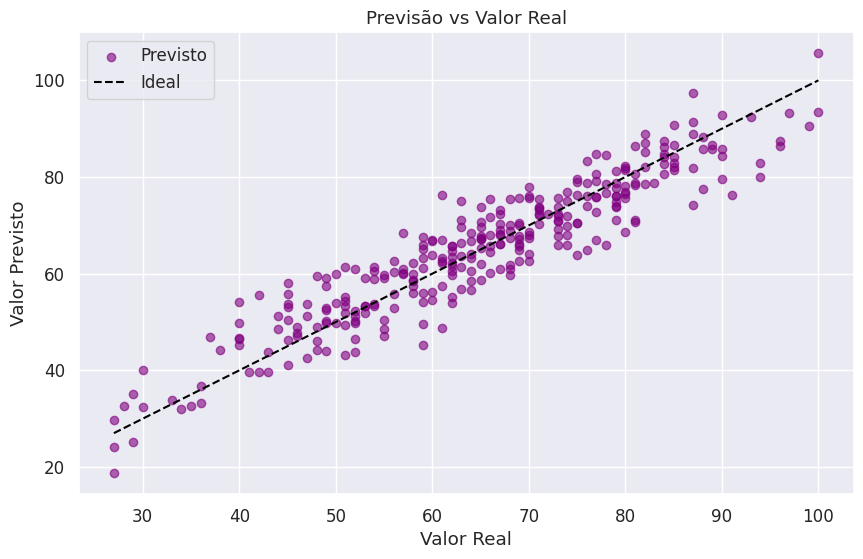

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multipla, color='purple', alpha=0.6, label='Previsto')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--', label='Ideal')

plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Previsão vs Valor Real')
plt.legend()
plt.show()

## Avaliação do modelo

In [ ]:
def avaliar_modelo(preds, y_test):
  mse = mean_squared_error(y_test, preds)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, preds)
  r2 = r2_score(y_test, preds)

  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"MAE: {mae:.2f}")
  print(f"R2: {r2:.2f}")

In [ ]:
# Regressão Linear Simples
avaliar_modelo(y_pred_simples, y_test)

MSE: 80.18
RMSE: 8.95
MAE: 7.41
R2: 0.66


In [ ]:
# Regressão Linear Múltipla
avaliar_modelo(y_pred_multipla, y_test)

MSE: 30.78
RMSE: 5.55
MAE: 4.40
R2: 0.87


## Análise dos Resíduos

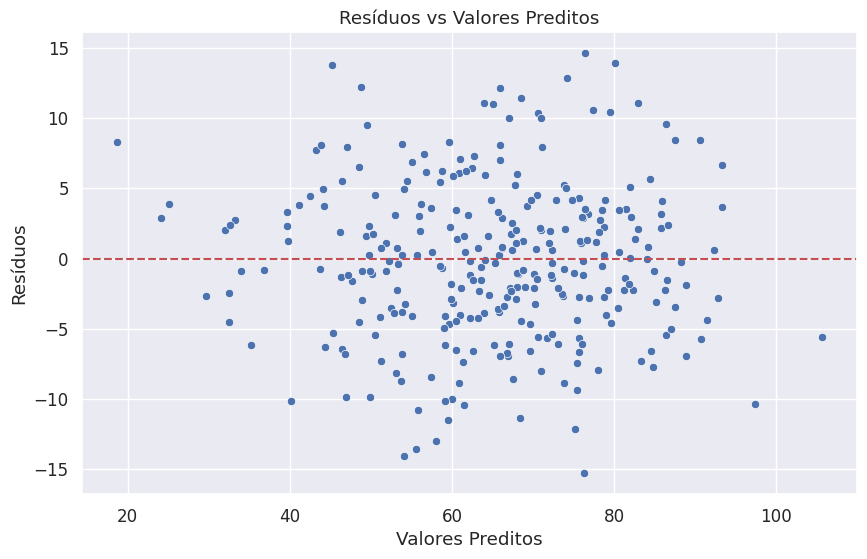

In [ ]:
residuos = y_test - y_pred_multipla

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multipla, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Preditos')
plt.show()

## Regularização

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [ ]:
y_ridge = ridge.predict(X_test)
avaliar_modelo(y_ridge, y_test)

MSE: 31.00
RMSE: 5.57
MAE: 4.40
R2: 0.87


In [ ]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

In [ ]:
y_lasso = lasso.predict(X_test)
avaliar_modelo(y_lasso, y_test)

MSE: 30.79
RMSE: 5.55
MAE: 4.40
R2: 0.87


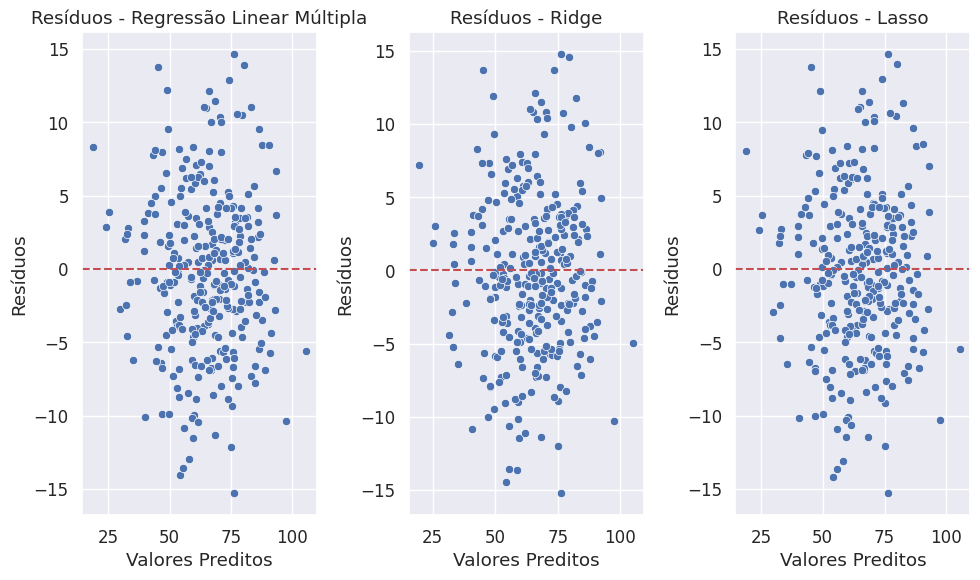

In [ ]:
residuos_linear = y_test - y_pred_multipla
residuos_ridge = y_test - y_ridge
residuos_lasso = y_test - y_lasso

plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_multipla, y=residuos_linear)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.title("Resíduos - Regressão Linear Múltipla")

plt.subplot(1, 3, 2)
sns.scatterplot(x=y_ridge, y=residuos_ridge)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.title("Resíduos - Ridge")

plt.subplot(1, 3, 3)
sns.scatterplot(x=y_lasso, y=residuos_lasso)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.title("Resíduos - Lasso")

plt.tight_layout()
plt.show()

## Modelo em cenário real

In [ ]:
joblib.dump(modelo_multiplo, "modelo_regressao.pkl")
joblib.dump(scaler, "normalizador.pkl")
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(list(X.columns), "colunas_modelo.pkl")

['colunas_modelo.pkl']

In [ ]:
class ModeloRegressao:
  def __init__(self):
    self.modelo = joblib.load("modelo_regressao.pkl")
    self.scaler = joblib.load("normalizador.pkl")
    self.ohe = joblib.load("onehot_encoder.pkl")
    self.colunas_modelo = joblib.load("colunas_modelo.pkl")

    self.colunas_categoricas = [
        "sex",
        "race/ethnicity",
        "parental_level_of_education",
        "lunch",
        "test_preparation_course"]

    self.colunas_numericas = [
        "reading_score",
        "writing_score"]

  def preprocess(self, df_novo):

    ohe_array = self.ohe.transform(df_novo[self.colunas_categoricas])
    ohe_cols = self.ohe.get_feature_names_out(self.colunas_categoricas)

    df_ohe = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_novo.index)

    df_num = df_novo.drop(columns=self.colunas_categoricas)

    df_final = pd.concat([df_num, df_ohe], axis=1)

    df_final = df_final.reindex(columns=self.colunas_modelo, fill_value=0)

    df_final[self.colunas_numericas] = df_final[self.colunas_numericas].astype(float)

    df_final.loc[:, self.colunas_numericas] = self.scaler.transform(
        df_final[self.colunas_numericas]
    )

    return df_final

  def predict(self, dados_aluno):
    if isinstance(dados_aluno, dict):
      df_novo = pd.DataFrame([dados_aluno])
    elif isinstance(dados_aluno, pd.DataFrame):
      df_novo = dados_aluno.copy()
    else:
      raise ValueError

    df_processado = self.preprocess(df_novo)
    pred = self.modelo.predict(df_processado)[0]

    return pred.round(2)

In [ ]:
novo_aluno = {
    "sex": "female",
    "race/ethnicity": "group B",
    "parental_level_of_education": "high school",
    "lunch": "standard",
    "test_preparation_course": "none",
    "reading_score": 72,
    "writing_score": 68
}

In [ ]:
regressor = ModeloRegressao()
resultado = regressor.predict(novo_aluno)
print(f"A nota prevista é: {resultado}")

A nota prevista é: 63.31
